In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset

# --! define known data properties
timeseries_len  = 200
timestep        = 0.001
dataset_dir     = 'cavity/train_10Hz_24Hz'
x_len           = 200

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. displacement
x_dims_n = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1


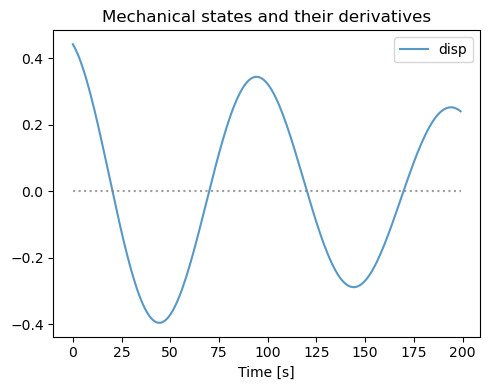

In [3]:
data_i = 123
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.title('Mechanical states and their derivatives')
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='disp')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model = care.detune()

inf >> Number of data files for training : 4
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4


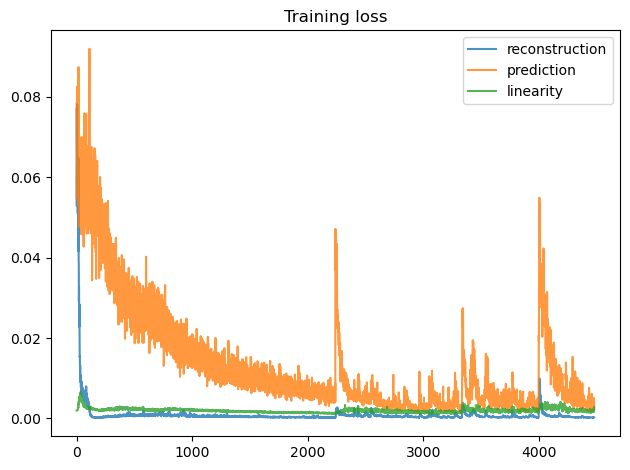

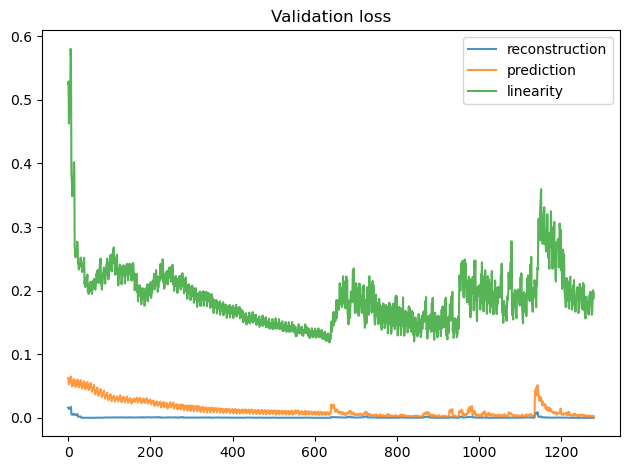

inf >> reconstruction loss in training is 1.008041e-03
inf >> prediction loss in training is 1.332720e-02
inf >> linearity loss in training is 1.962576e-03


In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation

bat_sz = 128

# --! make validation datasets and loaders
#dataset_valid = torch.utils.data.TensorDataset(data_valid)
#dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)

# --! specify optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-8)

# --! empty arrays to gather statistics
loss_train_recon = []
loss_train_pred  = []
loss_train_lin   = []

loss_valid_recon = []
loss_valid_pred  = []
loss_valid_lin   = []

# --! training duration
datafiles_train_n = 4
epochs_n          = 40
print(f"inf >> Number of data files for training : {datafiles_train_n}")

# --! prepare validation dataset
dataset_valid = torch.utils.data.TensorDataset(data_valid)

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x  = data[0][:, :x_len, :1] # take only displacement
            u  = data[0][:, :x_len, x_dims_n:]

            optimizer.zero_grad()

            global_only = True if datafile_train < 2 else False

            # --! fit a model to training data
            loss, loss_ae, loss_pred, loss_lin = model.fit(x, global_only)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_recon.append(loss_ae)
                loss_train_pred.append(loss_pred)
                loss_train_lin.append(loss_lin)

        # --! validate results
        with torch.no_grad():
            dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)
            for data in dataloader_valid:
                x  = data[0][:, :x_len, :1] # take only displacement

                # --! validate prediction
                funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(x, global_only)
                loss_valid_recon.append(torch.mean((x - timeseries_recon)**2))
                loss_valid_pred.append(torch.mean((x - timeseries_pred)**2))
                loss_valid_lin.append(torch.mean((funs - funs_pred)**2))

# --! display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_train_recon_mean = np.mean(loss_train_recon)
    loss_train_pred_mean = np.mean(loss_train_pred)
    loss_train_lin_mean = np.mean(loss_train_lin)
    print(f'inf >> reconstruction loss in training is {loss_train_recon_mean:e}')
    print(f'inf >> prediction loss in training is {loss_train_pred_mean:e}')
    print(f'inf >> linearity loss in training is {loss_train_lin_mean:e}')


In [6]:
with torch.no_grad():
    # --! make validation datasets and loaders
    dataset_test = torch.utils.data.TensorDataset(data_test)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bat_sz, shuffle=False)

    loss_test_recon = []
    loss_test_pred = []

    for data in dataloader_test:
        x  = data[0][:, :x_len, :x_dims_n]

        funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(x, global_only=False)
        loss_test_recon.append(torch.mean((x - timeseries_recon)**2))
        loss_test_pred.append(torch.mean((x - timeseries_pred)**2))

    loss_test_recon_mean = np.mean(loss_test_recon)
    loss_test_pred_mean = np.mean(loss_test_pred)
    # (torch.einsum) 1.533968e-04 -> (power mat) 1.297748e-04 -> (slice 50) 1.744521e-04 -> 6.341958e-05
    print(f'inf >> reconstruction loss in test is {loss_test_recon_mean:e}')
    # 2.632748e-03 -> 2.393762e-03 -> 9.944398e-04 -> 3.932714e-04
    print(f'inf >> prediction loss in test is {loss_test_pred_mean:e}')

inf >> reconstruction loss in test is 2.019951e-04
inf >> prediction loss in test is 2.733347e-03


0.0
tensor([[[0.2189, 0.0028, 0.3926, 0.1960, 0.1896],
         [0.2170, 0.0033, 0.3169, 0.2571, 0.2056],
         [0.2203, 0.0034, 0.3879, 0.1966, 0.1918],
         [0.2211, 0.0037, 0.3583, 0.2174, 0.1995],
         [0.2227, 0.0046, 0.3678, 0.2068, 0.1981]]])


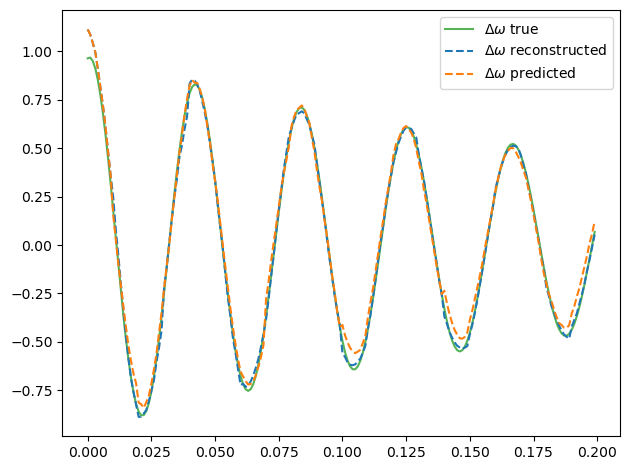

In [66]:
with torch.no_grad():
    data_i  = 88
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:x_len, :1], dim=0)
    funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(
        timeseries,
        global_only=False,
        alpha=0.21) # 45 -> 0.235, 444 -> 0.235, 123 -> 0.22

    print(timeseries_dyn_mat)
    print(funs_dyn_mat)

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_recon = torch.squeeze(timeseries_recon, dim=0)
    timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

    t = np.arange(0., x_len*timestep, timestep)

    plt.figure()
    plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
    plt.plot(t, timeseries_pred[:, 0], alpha=1, color='tab:orange', linestyle='dashed', label='$\\Delta \\omega$ predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()

0.0
tensor([[[0.8639, 0.0081, 0.0048, 0.0062, 0.1170],
         [0.9199, 0.0039, 0.0015, 0.0021, 0.0726],
         [0.8778, 0.0091, 0.0042, 0.0054, 0.1035],
         [0.8784, 0.0083, 0.0041, 0.0053, 0.1039],
         [0.8950, 0.0051, 0.0027, 0.0036, 0.0936]]])


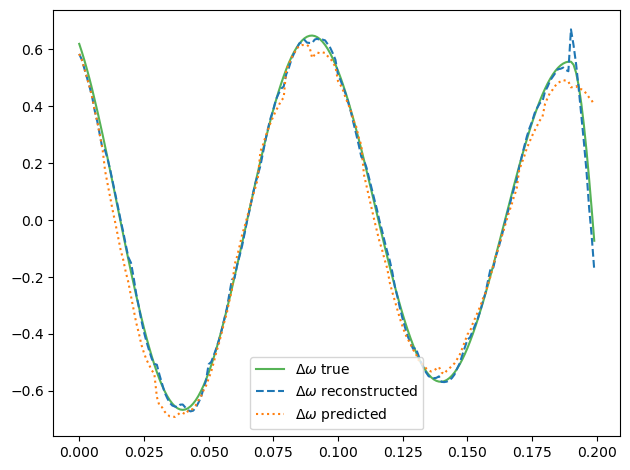

0.0
tensor([[[0.2749, 0.6072, 0.0030, 0.0034, 0.1116],
         [0.2852, 0.5787, 0.0050, 0.0057, 0.1254],
         [0.2869, 0.5563, 0.0058, 0.0061, 0.1449],
         [0.2892, 0.5476, 0.0072, 0.0077, 0.1483],
         [0.2702, 0.6142, 0.0022, 0.0024, 0.1110]]])


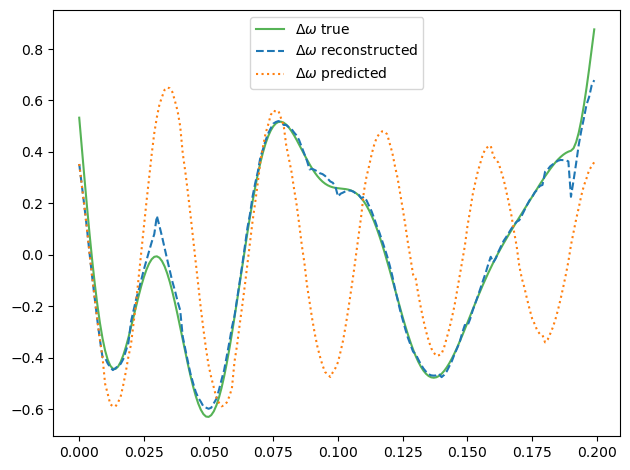

0.0
tensor([[[0.0279, 0.1783, 0.2864, 0.2113, 0.2961],
         [0.0158, 0.1491, 0.3189, 0.2053, 0.3109],
         [0.0489, 0.1419, 0.3274, 0.2093, 0.2724],
         [0.0720, 0.1517, 0.3086, 0.2089, 0.2589],
         [0.0610, 0.1380, 0.3301, 0.2073, 0.2635]]])


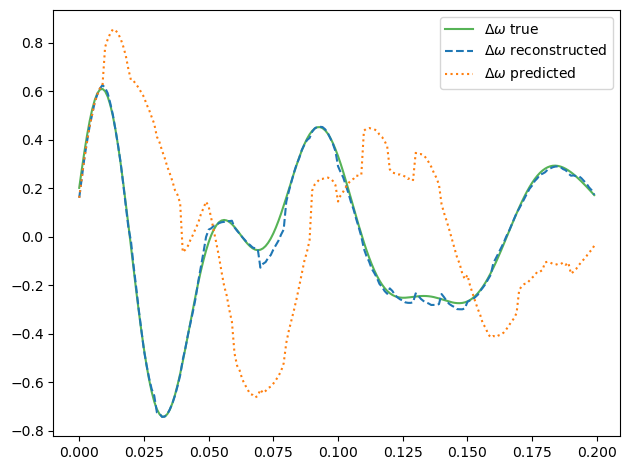

0.0
tensor([[[9.8623e-01, 2.9229e-03, 2.2780e-03, 1.8030e-03, 6.7670e-03],
         [9.7394e-01, 5.6017e-03, 4.9191e-03, 3.0476e-03, 1.2487e-02],
         [9.8129e-01, 3.9420e-03, 3.3306e-03, 2.1469e-03, 9.2908e-03],
         [9.5728e-01, 9.4263e-03, 8.2007e-03, 5.5946e-03, 1.9503e-02],
         [9.9110e-01, 1.7816e-03, 1.4919e-03, 8.6657e-04, 4.7625e-03]]])


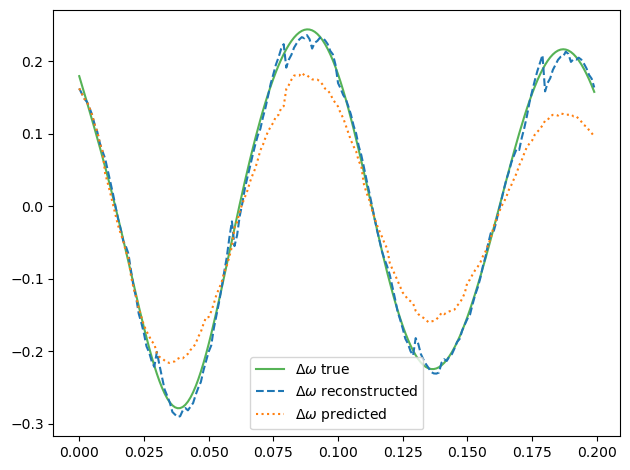

0.0
tensor([[[0.9310, 0.0022, 0.0540, 0.0091, 0.0037],
         [0.8302, 0.0099, 0.1121, 0.0310, 0.0168],
         [0.9483, 0.0012, 0.0422, 0.0060, 0.0023],
         [0.9341, 0.0018, 0.0522, 0.0085, 0.0035],
         [0.9067, 0.0033, 0.0700, 0.0137, 0.0063]]])


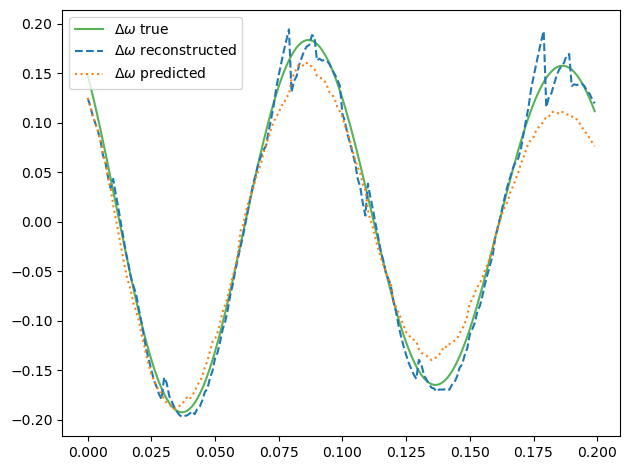

In [73]:
eval_ts_len       = 200
eval_timestep     = 0.001
eval_dataset_dir  = 'cavity/eval_10Hz_24Hz'

eval_data = utils.read_datafile(f'{eval_dataset_dir}/eval1', eval_ts_len)

with torch.no_grad():
    data = torch.split(eval_data, 1, dim=0)
    for datum in data:
        outs = model(datum, global_only=False, alpha=0.27)

        print(outs[4])
        print(outs[5])

        timeseries = torch.squeeze(datum, dim=0)
        timeseries_recon = torch.squeeze(outs[2], dim=0)
        timeseries_pred = torch.squeeze(outs[3], dim=0)

        t = np.arange(0., eval_ts_len*eval_timestep, eval_timestep)

        plt.figure()
        plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
        plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
        plt.plot(t, timeseries_pred[:, 0], alpha=1, color='tab:orange', linestyle='dotted', label='$\\Delta \\omega$ predicted')
        plt.legend()
        plt.tight_layout()
        plt.show()